[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/A5_regression_analysis.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a technique at work rather than on the full exercise scaffolding. This appendix needs **no optional installs** — it runs entirely on libraries bundled with the course requirements (`statsmodels`, `scikit-learn`), so you can read and run it 100% offline.

---
# 📓 Notebook A5 (DS) — Regression Analysis: From Correlation to Explanation

> **Module:** Data Science · **Type:** Appendix · **Estimated time:** 60–75 min · **Difficulty:** Intermediate

Notebook 10 taught you to compare **two groups** honestly (CI, t-test, effect size). But most business questions aren't two-group questions — they sound like *"which of these five factors actually drives the number I care about, and by how much?"* That question is what **regression analysis** answers, and it is the single most-used statistical tool in business data science: it powers pricing, forecasting with drivers, marketing-mix models, churn analysis — and it is the direct ancestor of every ML model you'll meet in Module 5.

> 🧭 **One question, all the way through.** We simulate the monthly bill of 300 customers of our LLM API business — each with a **segment**, **seats**, **monthly calls**, **average tokens per call**, and **support tickets** — and keep asking one thing: *"Which factors actually drive a customer's monthly spend — and by how much per unit?"* Because we simulate the data ourselves, we **know the true answer** and can check whether regression recovers it. That's the superpower of this notebook: you get to grade the method against ground truth. (Spoiler: the *coefficients* will land close to the truth. The model's first attempt at *error bars* will not — and catching that lie is half the lesson.)

> 🧠 **The mental model that ties it together.** A regression coefficient is just a **sample statistic** — exactly like the sample mean in Notebook 10. It has a sampling distribution, a standard error, a confidence interval, and a p-value, and every one of those means the same thing it meant there. If you understood §4–§5 of Notebook 10, you already understand 80% of the OLS summary table; this notebook supplies the remaining 20%.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Fit **simple and multiple linear regression** with statsmodels' formula API — and once by hand, so it never feels like magic.
2. Read **every number** in an OLS summary table: coefficient, standard error, t, p, confidence interval, R² / adjusted R².
3. Interpret coefficients as *"holding the other predictors constant"* — and explain **confounding / omitted-variable bias** with a live demonstration.
4. Handle **categorical predictors** with dummy variables.
5. Check the model with **residual diagnostics**, detect **heteroscedasticity**, and fix your standard errors with **robust (HC3) errors**.
6. Detect **multicollinearity** with the VIF.
7. Produce predictions with honest uncertainty — and explain the difference between a **confidence interval** and a **prediction interval**.
8. Say when to reach for **statsmodels** (inference) vs **scikit-learn** (prediction).

## 1. Setup

Three familiar imports plus two statsmodels entry points: `statsmodels.formula.api` (the R-style formula interface — you describe the model as a string) and `statsmodels.api` (utilities).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

RNG = np.random.default_rng(seed=42)

## 2. The dataset — 300 customers, and the ground truth

We simulate the monthly bill of 300 customers of our LLM API product. Each customer has:

| Column | Meaning |
|---|---|
| `segment` | `Startup` / `SMB` / `Enterprise` — the pricing tier |
| `seats` | Number of developer seats on the account |
| `monthly_calls` | API calls made this month (correlated with seats — bigger teams call more) |
| `avg_tokens` | Average tokens per call |
| `support_tickets` | Tickets filed this month |
| `monthly_spend` | 💰 The outcome we want to explain, in $ |

**The true data-generating process** — the thing regression will try to recover — is:

```
spend = 200  +  0.30·calls  +  12·seats  +  0.10·avg_tokens  +  0·tickets  +  segment bonus  +  noise
                                                                (SMB +150, Enterprise +450)
```

Two traps are built in on purpose:

- **`support_tickets` has a true coefficient of 0** — it does *nothing*. A good analysis must say so.
- The **noise grows with account size** (bigger accounts are more erratic). This is called *heteroscedasticity*, and §7 will catch it.

In [2]:
n = 300

# Segment, then seats *per segment* (bigger tier → more seats)
segment = RNG.choice(["Startup", "SMB", "Enterprise"], size=n, p=[0.45, 0.35, 0.20])
seats = np.select(
    [segment == "Startup", segment == "SMB", segment == "Enterprise"],
    [RNG.integers(2, 15, n), RNG.integers(10, 60, n), RNG.integers(40, 160, n)],
)

# Calls travel WITH seats (a confounder we'll expose in §5)
monthly_calls = (seats * RNG.normal(150, 60, n) + RNG.normal(0, 300, n)).clip(min=50)
avg_tokens = RNG.normal(1200, 250, n).clip(min=300)
support_tickets = RNG.poisson(4, n)

# ── The TRUE model (the answer key we'll grade regression against) ──
TRUE = {"Intercept": 200.0, "monthly_calls": 0.30, "seats": 12.0,
        "avg_tokens": 0.10, "support_tickets": 0.0,
        "SMB bonus": 150.0, "Enterprise bonus": 450.0}
segment_bonus = np.select(
    [segment == "Startup", segment == "SMB", segment == "Enterprise"],
    [0.0, TRUE["SMB bonus"], TRUE["Enterprise bonus"]],
)
noise = RNG.normal(0, 60 + 3.5 * seats)          # ⚠️ spread grows with seats!

monthly_spend = (TRUE["Intercept"]
                 + TRUE["monthly_calls"] * monthly_calls
                 + TRUE["seats"] * seats
                 + TRUE["avg_tokens"] * avg_tokens
                 + segment_bonus + noise)

df = pd.DataFrame({"segment": segment, "seats": seats,
                   "monthly_calls": monthly_calls.round(0),
                   "avg_tokens": avg_tokens.round(0),
                   "support_tickets": support_tickets,
                   "monthly_spend": monthly_spend.round(2)})
df.head()

,segment,seats,monthly_calls,avg_tokens,support_tickets,monthly_spend
0,SMB,10,1544.0,1010.0,3,1207.75
1,Startup,12,2707.0,1060.0,4,1146.43
2,Enterprise,158,2202.0,1194.0,4,4140.27
3,SMB,54,3436.0,809.0,9,1946.18
4,Startup,12,503.0,1257.0,2,826.01


In [3]:
df.describe().round(1)

,seats,monthly_calls,avg_tokens,support_tickets,monthly_spend
count,300.0,300.0,300.0,300.0,300.0
mean,35.9,5106.9,1187.7,4.0,2411.9
std,40.3,6442.2,261.1,1.9,2471.5
min,2.0,50.0,461.0,0.0,196.4
25%,9.0,1228.2,1018.8,3.0,798.7
50%,15.5,2633.0,1191.5,4.0,1441.3
75%,47.0,6595.2,1341.8,5.0,3156.9
max,158.0,35066.0,1929.0,11.0,13431.8


### Visualise before you model — *always*

Same mantra as Notebook 10: look at the data before you summarise it. Spend vs calls, coloured by segment, plus the distribution of spend itself.

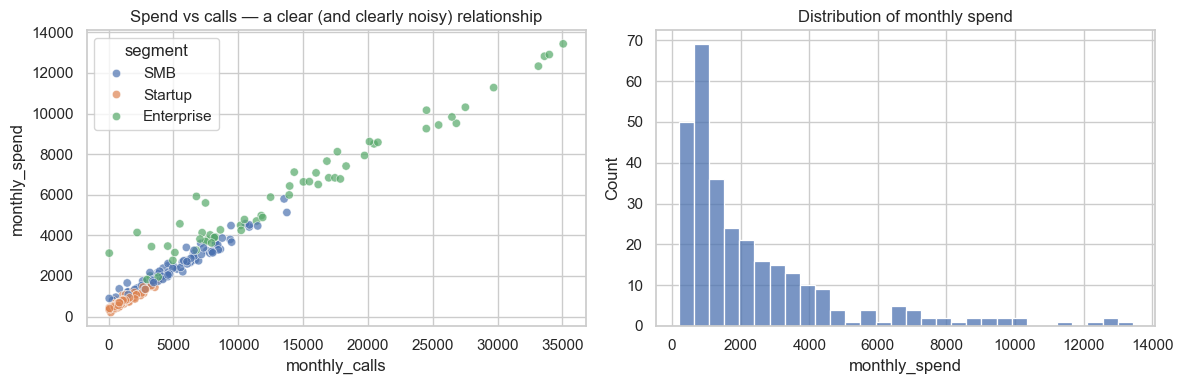

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x="monthly_calls", y="monthly_spend",
                hue="segment", alpha=0.7, ax=axes[0])
axes[0].set_title("Spend vs calls — a clear (and clearly noisy) relationship")
sns.histplot(df["monthly_spend"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of monthly spend")
plt.tight_layout()

**Reading what you see:**

- Spend rises with calls — but with **spread**, and the spread *widens* as calls grow (remember that for §7).
- The segments occupy different regions: Enterprise accounts are far right *and* high. Calls, seats and segment all travel together — so which one is doing the work? Correlation alone can't tell you. That's the job of §5.

## 3. Correlation is not enough

The obvious first move is a correlation matrix — and it's a fine first move. But watch what it *can't* do.

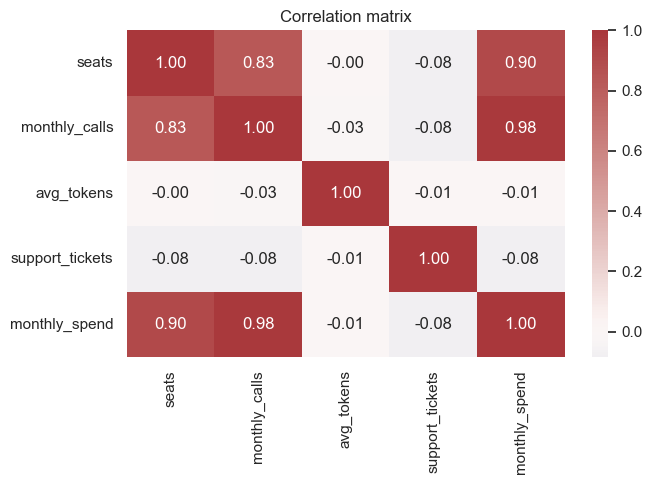

In [5]:
num_cols = ["seats", "monthly_calls", "avg_tokens", "support_tickets", "monthly_spend"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="vlag",
            center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()

Three things correlation **cannot** give you:

1. **Units.** `corr(calls, spend) ≈ 0.98` doesn't answer *"what does one extra call cost?"* — a number you can put in a pricing meeting.
2. **Adjustment.** `seats` and `monthly_calls` are themselves correlated (r ≈ 0.83). Their correlations with spend double-count each other; correlation has no way to ask *"what does calls contribute once seats is accounted for?"*
3. **Uncertainty.** No standard error, no CI, no test.

Regression delivers all three: coefficients **in the outcome's units**, **holding the other predictors constant**, **with confidence intervals**. That's the whole sales pitch.

## 4. Simple regression — one predictor, by hand first

### 🔬 What actually happens — least squares in two lines

A simple linear regression fits the line `spend = β₀ + β₁·calls` by choosing the β's that minimise the **sum of squared residuals** (a residual is *actual − predicted*, the vertical miss of the line). For one predictor, calculus hands you a closed form:

$$\hat\beta_1 = \frac{\mathrm{cov}(x, y)}{\mathrm{var}(x)} \qquad \hat\beta_0 = \bar y - \hat\beta_1\,\bar x$$

That's it — the "learning" in a linear model is a covariance divided by a variance. Let's do it by hand, then let statsmodels confirm.

In [6]:
x, y = df["monthly_calls"], df["monthly_spend"]

beta1 = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)
beta0 = y.mean() - beta1 * x.mean()

print(f"By hand:  spend ≈ {beta0:.1f} + {beta1:.4f} · calls")
print(f"→ each extra call is associated with ≈ ${beta1:.3f} of extra spend")

By hand:  spend ≈ 485.4 + 0.3772 · calls
→ each extra call is associated with ≈ $0.377 of extra spend


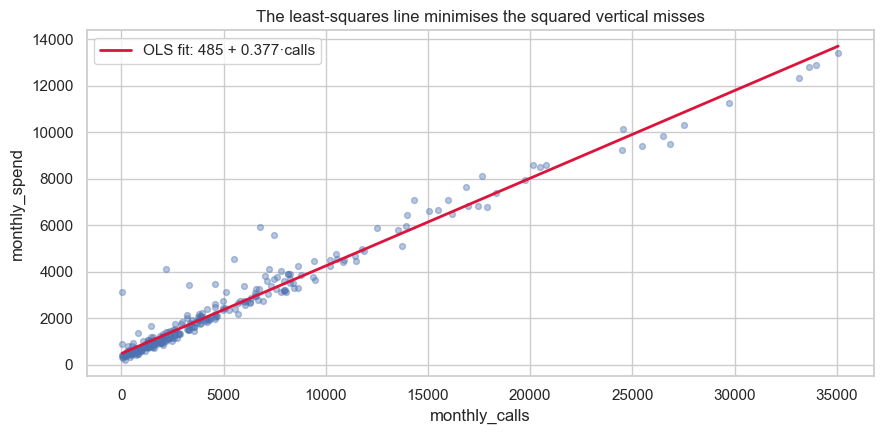

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(x, y, alpha=0.4, s=18)
grid = np.linspace(x.min(), x.max(), 100)
ax.plot(grid, beta0 + beta1 * grid, color="crimson", lw=2,
        label=f"OLS fit: {beta0:.0f} + {beta1:.3f}·calls")
ax.set(xlabel="monthly_calls", ylabel="monthly_spend",
       title="The least-squares line minimises the squared vertical misses")
ax.legend()
plt.tight_layout()

### The same fit with statsmodels — and the famous summary table

The formula string `"monthly_spend ~ monthly_calls"` reads as *"model spend as a function of calls"*. statsmodels adds the intercept automatically.

In [8]:
model_simple = smf.ols("monthly_spend ~ monthly_calls", data=df).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     8714.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          1.15e-222
Time:                        22:23:31   Log-Likelihood:                -2257.6
No. Observations:                 300   AIC:                             4519.
Df Residuals:                     298   BIC:                             4527.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       485.3725     33.189     14.625

### How to read the summary — the only four columns you need daily

| Column | Meaning | Notebook 10 sibling |
|---|---|---|
| `coef` | Best estimate of the effect, **in outcome units per predictor unit** | the sample mean |
| `std err` | Standard error — the spread of the coefficient's **sampling distribution** | `SE = σ/√n` |
| `P>\|t\|` | p-value for H₀: *"the true coefficient is 0"* | the t-test p-value |
| `[0.025, 0.975]` | 95% confidence interval for the coefficient | the CI of the mean |

And one headline number: **R-squared** — the share of the variance in spend that the model explains (here ≈ 0.97 — calls is that dominant a driver).

> 🧠 **Mental model.** Rerun this month with 300 *different* customers and you'd get a slightly different `coef` — the coefficient is a random variable with its own sampling distribution, and `std err` is that distribution's spread. A CI, a t-statistic and a p-value then mean *exactly* what they meant in Notebook 10. Nothing new was invented for regression.

But notice the slope: **≈ $0.38 per call — the truth is $0.30, a 26% overstatement.** Not a rounding error, and not bad luck. The simple model is *biased*, and §5 shows why.

---

### ✋ Quick exercise 1 (~2 min) — Fit `spend ~ seats` by hand

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Compute the slope and intercept of `monthly_spend ~ seats` using the cov/var formula, then confirm with `smf.ols`. Is the slope anywhere near the true value of 12 $/seat? Why not? (Hint: what else do big-seat accounts have a lot of?)

In [9]:
# ✍️ Your turn 👇
# Slope and intercept of monthly_spend ~ seats, by hand and with smf.ols.


<details>
<summary>✅ <b>Solution</b></summary>

```python
xs = df["seats"]
b1 = np.cov(xs, y, ddof=1)[0, 1] / np.var(xs, ddof=1)
b0 = y.mean() - b1 * xs.mean()
print(f"by hand:      spend ≈ {b0:.1f} + {b1:.2f}·seats")
print(smf.ols("monthly_spend ~ seats", data=df).fit().params.round(2))
```

The slope comes out around **55–60 $/seat — nearly 5× the true 12 $/seat**. It isn't wrong arithmetic; it's *confounding*: accounts with many seats also make many calls, and this one-predictor model hands all the credit for those calls to `seats`. Fixing exactly this is the point of multiple regression (§5).
</details>

## 5. Multiple regression — "holding everything else constant"

The fix for confounding is to put **all** the candidate drivers in one model and let least squares divide the credit:

- `C(segment, Treatment(reference="Startup"))` turns the text column into **dummy variables** (0/1 indicators for SMB and Enterprise, with Startup as the baseline — so each segment coefficient reads *"vs a Startup account"*).
- Every numeric coefficient now means *"the effect of a one-unit change in this predictor, **holding the others fixed**"*.

In [10]:
formula = ("monthly_spend ~ monthly_calls + seats + avg_tokens "
           "+ support_tickets + C(segment, Treatment(reference='Startup'))")
model_full = smf.ols(formula, data=df).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     6264.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          4.94e-306
Time:                        22:23:31   Log-Likelihood:                -2039.7
No. Observations:                 300   AIC:                             4093.
Df Residuals:                     293   BIC:                             4119.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

### 🔮 Predict the output

The simple model said each call is worth ≈ $0.34. The full model holds `seats` and `segment` fixed while it evaluates `monthly_calls`. Before scrolling to the next cell: will the calls coefficient go **up**, go **down**, or **stay the same** — and what should the `support_tickets` coefficient look like?

<details>
<summary>🔮 <b>Answer</b></summary>

**Down — towards the truth.** In the simple model, `monthly_calls` was collecting credit that actually belongs to seats and segment (they all rise together). Once those are held constant, the calls coefficient falls to ≈ 0.29 — within a whisker of the true 0.30. And `support_tickets` should be **near 0 with a large p-value**: it truly does nothing, and the model should say so.
</details>

### Grading regression against the answer key

We *know* the true coefficients — we wrote them. Time to grade.

In [11]:
name_map = {
    "Intercept": "Intercept",
    "monthly_calls": "monthly_calls",
    "seats": "seats",
    "avg_tokens": "avg_tokens",
    "support_tickets": "support_tickets",
    "C(segment, Treatment(reference='Startup'))[T.SMB]": "SMB bonus",
    "C(segment, Treatment(reference='Startup'))[T.Enterprise]": "Enterprise bonus",
}
ci = model_full.conf_int().rename(columns={0: "ci_low", 1: "ci_high"})
report = pd.DataFrame({
    "true": [TRUE[name_map[p]] for p in model_full.params.index],
    "estimated": model_full.params,
    "ci_low": ci["ci_low"], "ci_high": ci["ci_high"],
    "p_value": model_full.pvalues,
}).round(3)
report["truth_in_CI"] = (report["true"] >= report["ci_low"]) & (report["true"] <= report["ci_high"])
report

,true,estimated,ci_low,ci_high,p_value,truth_in_CI
Intercept,200.0,96.734,-35.802,229.269,0.152,True
"C(segment, Treatment(reference='Startup'))[T.Enterprise]",450.0,252.500,100.057,404.942,0.001,False
"C(segment, Treatment(reference='Startup'))[T.SMB]",150.0,109.828,42.802,176.854,0.001,True
monthly_calls,0.3,0.288,0.281,0.295,0.000,False
seats,12.0,15.237,13.572,16.902,0.000,False
avg_tokens,0.1,0.162,0.066,0.258,0.001,True
support_tickets,0.0,5.246,-7.873,18.365,0.432,True


**What the answer key says — read it in two passes:**

- **The point estimates are good.** `monthly_calls` ≈ 0.29 — the confounded 0.38 from §4 snapped back toward the truth once seats and segment were held constant. `seats` ≈ 15 — nowhere near the wild ~55 the one-predictor model claimed in Quick exercise 1. And `support_tickets` ≈ 5 with p ≈ 0.4 — statistically indistinguishable from its true value of 0; the model refuses to invent an effect that isn't there.
- **But look at the `truth_in_CI` column: three of the seven true values fall *outside* their 95% CIs** (calls, seats, and the Enterprise bonus — the model claims ≈$250 with a tight interval when the planted truth is $450). If these intervals were honest 95% intervals, missing 3 of 7 would be a one-in-hundreds fluke.
- **Verdict:** the coefficients are fine; the *stated precision* is a lie. Hold that thought — §7 finds the culprit (the funnel we planted in the noise) and fixes the error bars.

> 🚫 **Misconception — "the model with the highest correlation wins."** Leaving a relevant variable *out* doesn't make its effect disappear — it makes the remaining coefficients absorb it. That is **omitted-variable bias**, and you just watched it happen (twice). It is also why "we regressed revenue on marketing spend and the coefficient was huge!" should always prompt: *what did you hold constant?*

---

### ✋ Quick exercise 2 (~2 min) — Read the dummies

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

From the `model_full` summary: (a) In plain English, what does the `Enterprise` coefficient mean — and what is it *not* saying? (b) Which predictors are statistically indistinguishable from "no effect" at the 5% level?

In [12]:
# ✍️ Your turn 👇
# (a) Interpret the Enterprise dummy in one sentence.
# (b) Which predictors have p > 0.05?


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(model_full.params.filter(like="Enterprise").round(1))
print(model_full.pvalues[model_full.pvalues > 0.05].round(3))
```

(a) *Holding calls, seats, tokens and tickets constant*, an Enterprise account spends about **$250 more per month than a Startup account** (the baseline). It is **not** the raw Enterprise-vs-Startup spend gap — that raw gap is thousands of dollars, but most of it flows through calls and seats, which the model credits separately. (The planted truth is $450; as §5's answer key showed, this coefficient's naive CI is one of the ones that lies. §7 repairs it.)

(b) `support_tickets` — exactly the planted decoy — plus the intercept, which is fine: the intercept is an anchor point, not a driver.
</details>

## 6. How good is the model? R², adjusted R², RMSE

In [13]:
def scorecard(name, model):
    rmse = float(np.sqrt(np.mean(model.resid ** 2)))
    return {"model": name, "R²": round(model.rsquared, 3),
            "adj. R²": round(model.rsquared_adj, 3),
            "RMSE ($)": round(rmse, 0), "params": int(model.df_model) + 1}

pd.DataFrame([scorecard("simple (calls only)", model_simple),
              scorecard("full (all drivers)", model_full)]).set_index("model")

,R²,adj. R²,RMSE ($),params
model,,,,
simple (calls only),0.967,0.967,449.0,2
full (all drivers),0.992,0.992,217.0,7


- **R²** — share of spend variance the model explains. The simple model already scores high because calls is such a dominant driver — high R² and *biased coefficients* at the same time. Let that sink in.
- **Adjusted R²** — R² with a penalty per predictor. Plain R² **never goes down** when you add a variable, even a junk one; adjusted R² only rises if the newcomer earns its keep. Always compare models on the adjusted number.
- **RMSE** — the typical prediction miss **in dollars**. "We predict a customer's bill to within ±$220" lands better in a meeting than any R².

> 🚫 **Misconception — "high R² means the model is right."** R² measures *fit*, not *truth*: the §4 model has an R² of ≈0.97 and a coefficient that's 26% off with a CI that excludes the true value. Conversely, a low-R² model can estimate its coefficients perfectly on noisy data. Judge coefficients with CIs and diagnostics — judge predictions with RMSE on held-out data (§10).

## 7. Diagnostics — trust, but verify

OLS inference (those std errs, p's and CIs) leans on assumptions about the **residuals**: roughly, that they are independent, centred on zero everywhere (*linearity*), equally spread everywhere (*homoscedasticity* — "same scatter"), and not too far from normal. You check all of that with two plots, not theorems:

1. **Residuals vs fitted** — should be a structureless horizontal band. Curvature ⇒ you missed a nonlinearity; a funnel ⇒ the spread grows with the prediction (**heteroscedasticity**).
2. **Q–Q plot** — residual quantiles vs normal quantiles; close to the diagonal is good.

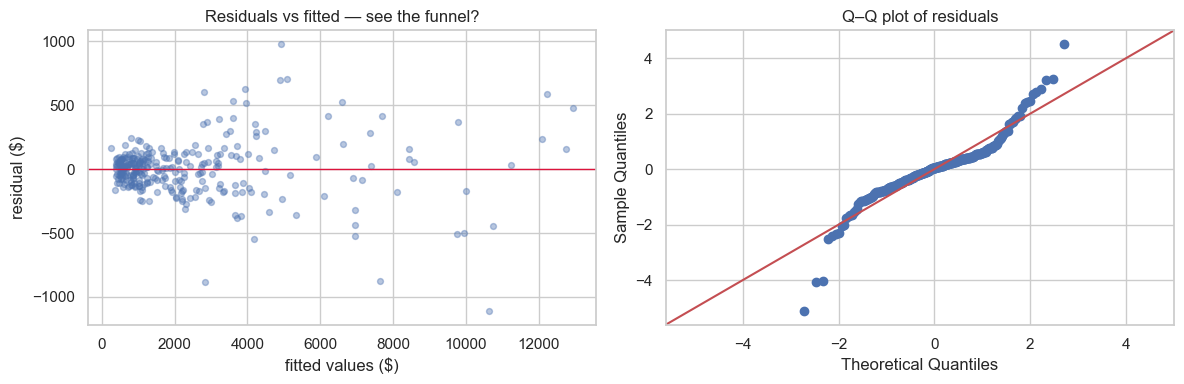

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(model_full.fittedvalues, model_full.resid, alpha=0.4, s=18)
axes[0].axhline(0, color="crimson", lw=1)
axes[0].set(xlabel="fitted values ($)", ylabel="residual ($)",
            title="Residuals vs fitted — see the funnel?")
sm.qqplot(model_full.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q–Q plot of residuals")
plt.tight_layout()

**The funnel is real — and planted.** We *built* the noise as `σ = 60 + 3.5·seats`, so big accounts are noisier and the residual spread widens to the right. The consequences, in order of importance:

- The **coefficients are still unbiased** — the funnel doesn't move them.
- The **standard errors are wrong** (usually too small) — so p-values and CIs are overconfident. That's the caveat promised in §5.

The lightest-touch fix: keep the same coefficients but compute **heteroscedasticity-robust standard errors** (statsmodels calls the standard flavour `HC3`). One argument, honest inference:

In [15]:
model_robust = model_full.get_robustcov_results(cov_type="HC3")

comparison = pd.DataFrame({
    "coef": model_full.params.round(3),
    "SE (naive)": model_full.bse.round(3),
    "SE (HC3 robust)": pd.Series(model_robust.bse, index=model_full.params.index).round(3),
})
comparison["SE ratio"] = (comparison["SE (HC3 robust)"] / comparison["SE (naive)"]).round(2)
comparison

,coef,SE (naive),SE (HC3 robust),SE ratio
Intercept,96.734,67.342,65.944,0.98
"C(segment, Treatment(reference='Startup'))[T.Enterprise]",252.500,77.457,114.804,1.48
"C(segment, Treatment(reference='Startup'))[T.SMB]",109.828,34.056,38.638,1.13
monthly_calls,0.288,0.004,0.008,2.00
seats,15.237,0.846,1.847,2.18
avg_tokens,0.162,0.049,0.053,1.08
support_tickets,5.246,6.666,6.822,1.02


Identical coefficients, honest (mostly wider) standard errors — and for `seats` and `monthly_calls`, the variables the funnel hits hardest, the naive SEs were less than **half** their honest size (ratio ≈ 2.2–2.3). In practice: **residual funnel → report HC3 errors** (or model the variance / transform the outcome; robust errors are the everyday tool). Other classical options: a log-transform of the outcome when effects are multiplicative, or weighted least squares when you know the variance structure.

### Re-grading against the answer key — with honest error bars

§5 ended on a cliffhanger: three of seven true values sat outside their naive CIs. Same coefficients, HC3 intervals, second attempt:

In [16]:
rob_ci = pd.DataFrame(np.asarray(model_robust.conf_int()),
                      index=model_full.params.index, columns=["ci_low", "ci_high"])
regrade = pd.DataFrame({
    "true": [TRUE[name_map[p]] for p in model_full.params.index],
    "estimated": model_full.params.round(3),
    "ci_low": rob_ci["ci_low"].round(3), "ci_high": rob_ci["ci_high"].round(3),
})
regrade["truth_in_CI"] = (regrade["true"] >= regrade["ci_low"]) & (regrade["true"] <= regrade["ci_high"])
regrade

,true,estimated,ci_low,ci_high,truth_in_CI
Intercept,200.0,96.734,-33.050,226.517,True
"C(segment, Treatment(reference='Startup'))[T.Enterprise]",450.0,252.500,26.554,478.445,True
"C(segment, Treatment(reference='Startup'))[T.SMB]",150.0,109.828,33.784,185.872,True
monthly_calls,0.3,0.288,0.271,0.304,True
seats,12.0,15.237,11.601,18.873,True
avg_tokens,0.1,0.162,0.057,0.267,True
support_tickets,0.0,5.246,-8.181,18.673,True


**All seven true values are now inside their intervals.** Nothing about the fit changed — only the honesty of the error bars. That's the moral of this section in one table: diagnostics aren't decoration; they decide whether a model's uncertainty statements mean anything at all.

---

### ✋ Quick exercise 3 (~2 min) — Diagnose the *simple* model

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Draw residuals-vs-fitted for `model_simple` (the calls-only model from §4). You should see **two** problems, not one. What are they, and which §5 concept explains the second?

In [17]:
# ✍️ Your turn 👇
# Residuals vs fitted for model_simple. What TWO patterns do you see?


<details>
<summary>✅ <b>Solution</b></summary>

```python
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(model_simple.fittedvalues, model_simple.resid, alpha=0.4, s=18)
ax.axhline(0, color="crimson", lw=1)
ax.set(xlabel="fitted ($)", ylabel="residual ($)",
       title="Simple model — residuals vs fitted")
```

1. The same **funnel** (heteroscedastic noise is in the data, so every model inherits it).
2. The band is not centred on zero everywhere — the residuals carry **structure**, because everything the model omitted (seats, segment, tokens) is still *in* the residuals. Omitted variables don't vanish; they hide in the residuals and bias the coefficients you kept — §5's omitted-variable bias, seen from the residual side.
</details>

## 8. Multicollinearity — when predictors overlap

"Holding seats constant, one more call adds $0.30" only works if calls and seats *can* move separately in the data. When two predictors travel almost in lockstep, least squares struggles to split the credit — the coefficients stay unbiased, but their standard errors **inflate**. The diagnostic is the **variance inflation factor (VIF)**: how many times larger the variance of a coefficient is than it would be with uncorrelated predictors. Rules of thumb: VIF > 5 deserves a look; VIF > 10 is a problem.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(df[["monthly_calls", "seats", "avg_tokens", "support_tickets"]])
vif = pd.DataFrame({
    "predictor": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).set_index("predictor").drop("const").round(2)
vif

,VIF
predictor,
monthly_calls,3.24
seats,3.23
avg_tokens,1.00
support_tickets,1.01


`monthly_calls` and `seats` land around **3** — their r ≈ 0.83 correlation inflates each coefficient's variance roughly 3×. That's a real cost (sharper answers were available from less entangled data), but comfortably below the trouble thresholds, and with n = 300 both coefficients still came out usable. If VIFs blow past 10, your options are: **drop** one of the twins, **combine** them (e.g. calls-per-seat), or **regularise** (ridge regression — Module 5 territory). What you should *not* do is stare at two unstable coefficients and interpret each as if the other weren't there.

> 💡 One more reason multicollinearity matters: it's the classic cause of the paradox *"the F-test says the model is great, but no individual predictor is significant."* The predictors jointly explain the outcome, but the data can't tell **which** of them deserves the credit.

## 9. Predicting with honest uncertainty

A new SMB customer signs up: **25 seats, 4,000 calls/month, 1,200 avg tokens, 3 tickets**. What will they spend? Two very different "±" answers exist, and mixing them up is a classic reporting error:

- **Confidence interval (of the mean):** where the *average* spend of many such customers lies. Narrow — it only carries coefficient uncertainty.
- **Prediction interval:** where *this one customer's* bill will land. Much wider — it adds the irreducible noise term on top.

(Same distinction as Notebook 10's CI-of-the-mean vs the spread of individuals — resurfacing here.)

In [19]:
new_customer = pd.DataFrame({"segment": ["SMB"], "seats": [25],
                             "monthly_calls": [4000], "avg_tokens": [1200],
                             "support_tickets": [3]})

pred = model_full.get_prediction(new_customer).summary_frame(alpha=0.05)
point = pred.loc[0, "mean"]
print(f"Point prediction:            ${point:,.0f}")
print(f"95% CI of the mean:          ${pred.loc[0,'mean_ci_lower']:,.0f} – ${pred.loc[0,'mean_ci_upper']:,.0f}")
print(f"95% prediction interval:     ${pred.loc[0,'obs_ci_lower']:,.0f} – ${pred.loc[0,'obs_ci_upper']:,.0f}   ← quote THIS one to the customer")

Point prediction:            $1,948
95% CI of the mean:          $1,902 – $1,995
95% prediction interval:     $1,513 – $2,383   ← quote THIS one to the customer


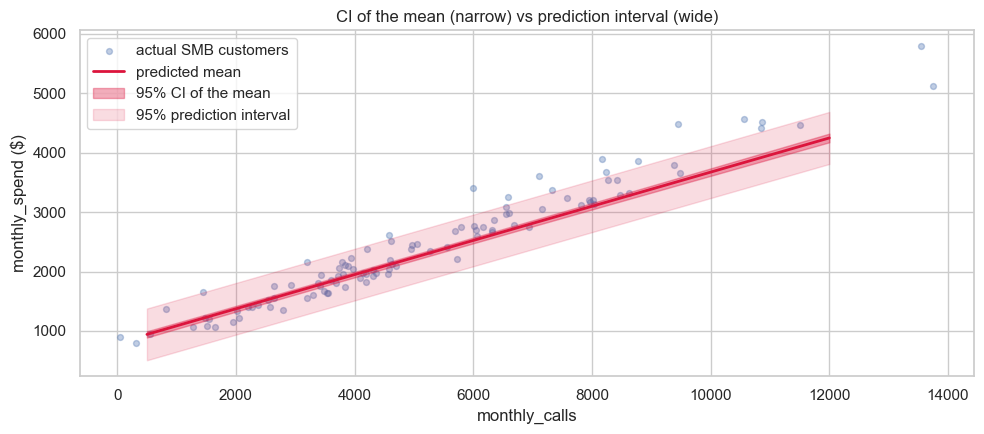

In [20]:
# The two intervals, drawn: sweep calls for a 25-seat SMB account
grid = pd.DataFrame({"segment": "SMB", "seats": 25,
                     "monthly_calls": np.linspace(500, 12000, 120),
                     "avg_tokens": 1200, "support_tickets": 3})
sweep = model_full.get_prediction(grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 4.5))
smb = df[df["segment"] == "SMB"]
ax.scatter(smb["monthly_calls"], smb["monthly_spend"], alpha=0.35, s=18,
           label="actual SMB customers")
ax.plot(grid["monthly_calls"], sweep["mean"], color="crimson", lw=2, label="predicted mean")
ax.fill_between(grid["monthly_calls"], sweep["mean_ci_lower"], sweep["mean_ci_upper"],
                alpha=0.35, color="crimson", label="95% CI of the mean")
ax.fill_between(grid["monthly_calls"], sweep["obs_ci_lower"], sweep["obs_ci_upper"],
                alpha=0.15, color="crimson", label="95% prediction interval")
ax.set(xlabel="monthly_calls", ylabel="monthly_spend ($)",
       title="CI of the mean (narrow) vs prediction interval (wide)")
ax.legend()
plt.tight_layout()

The narrow band answers *"where is the average?"*; the wide band answers *"where will one actual bill land?"* — and it's the wide band, not the narrow one, that actually contains the cloud of real customers. (We use the model's standard intervals here: a prediction interval's width is dominated by the irreducible noise term, so §7's standard-error caveat bites far less for prediction than it did for coefficient inference.) When someone asks "what will customer X spend?", the prediction interval is the honest answer; quoting the CI of the mean understates your uncertainty by a factor of several.

---

### ✋ Quick exercise 4 (~2 min) — Would an $8,000 bill be surprising?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

An **Enterprise** account with **100 seats, 20,000 calls, 1,200 avg tokens, 4 tickets** gets a bill of **$8,000**. Using `get_prediction`, decide: is that bill within the normal range for such an account, or should someone investigate?

In [21]:
# ✍️ Your turn 👇
# Build the one-row DataFrame, get the 95% prediction interval, compare to 8000.


<details>
<summary>✅ <b>Solution</b></summary>

```python
acct = pd.DataFrame({"segment": ["Enterprise"], "seats": [100],
                     "monthly_calls": [20000], "avg_tokens": [1200],
                     "support_tickets": [4]})
p = model_full.get_prediction(acct).summary_frame(alpha=0.05)
lo, hi = p.loc[0, "obs_ci_lower"], p.loc[0, "obs_ci_upper"]
print(f"predicted ${p.loc[0,'mean']:,.0f}, 95% PI ${lo:,.0f} – ${hi:,.0f}")
print("8000 inside PI:", lo <= 8000 <= hi)
```

The point prediction is ≈ $7,840 and the 95% prediction interval spans roughly $7,400–$8,300 — an $8,000 bill sits comfortably inside. **Not surprising; no investigation needed.** (This pattern — "is this observation inside its prediction interval?" — is a perfectly respectable baseline anomaly detector, and returns in Module 7's fraud notebook.)
</details>

## 10. From statistics to machine learning — same model, two mindsets

scikit-learn fits the *identical* line — but the workflow around it reveals a different goal. Statsmodels asks *"are these coefficients real?"*; sklearn asks *"how well does this predict data it hasn't seen?"* — so the sklearn ritual starts by **holding out a test set**.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X = pd.get_dummies(df.drop(columns="monthly_spend"), columns=["segment"], drop_first=True)
y_all = df["monthly_spend"]
X_train, X_test, y_train, y_test = train_test_split(X, y_all, test_size=0.25, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"held-out R²:   {r2_score(y_test, y_pred):.3f}")
print(f"held-out RMSE: ${root_mean_squared_error(y_test, y_pred):,.0f}")
print()
print("sklearn coefficients (same story as statsmodels):")
print(pd.Series(lr.coef_, index=X.columns).round(3))

held-out R²:   0.991
held-out RMSE: $265

sklearn coefficients (same story as statsmodels):
seats               14.575
monthly_calls        0.292
avg_tokens           0.165
support_tickets     -2.339
segment_SMB       -147.867
segment_Startup   -248.693
dtype: float64


| | **statsmodels** (inference) | **scikit-learn** (prediction) |
|---|---|---|
| Question | *Which drivers matter, and by how much?* | *How accurately can I predict new cases?* |
| Output | Summary table: SEs, p-values, CIs | `.predict()`, scores on held-out data |
| Evaluation | Diagnostics, robust SEs, CIs | Train/test split, cross-validation |
| Typical use | Analysis you present & defend | Models you deploy |

Same math, different contract. **Use statsmodels when the deliverable is understanding; use sklearn when the deliverable is predictions.** Module 5 (Notebooks 17–19) picks up the sklearn thread properly — pipelines, cross-validation, and regularised cousins of this model (ridge, lasso) that trade a little bias for stability exactly when VIFs explode. And appendix A1 connects regression to *forecasting*: SARIMAX's "X" is literally a regression bolted onto a time-series model.

## 11. The classical regression mistakes (and the fixes)

1. **Extrapolation.** The model saw calls between ~50 and ~35,000. Predicting a 100,000-call account means trusting the line where there is no data. *Fix: check the new point against the training ranges; refuse politely outside them.*
2. **Reading causation off an observational fit.** Our coefficients recover the truth because we *simulated* the mechanism. In real data, "coefficient of tickets on churn = 0.3" does not mean closing tickets prevents churn — unmeasured confounders can fake it. *Fix: causal language needs an experiment (Notebook 10!) or explicit causal methods; otherwise say "is associated with".*
3. **Kitchen-sink fishing.** Throw 40 predictors at 300 rows and ~2 will clear p < 0.05 by luck — the multiple-comparisons trap from Notebook 10 §9 wearing a new hat. *Fix: choose predictors for reasons, or hold out data and validate.*
4. **Skipping the residual plots.** Funnels and curves silently invalidate every p-value in the table — the summary won't warn you. *Fix: the two plots of §7, every time; robust (HC3) errors when in doubt.*
5. **Quoting the CI of the mean as if it bounded individual outcomes.** §9's two bands differ by a factor of several. *Fix: prediction intervals for individual cases.*

## 🧪 Practice exercises

### Exercise 1 — ⭐ The Startup-only model

Fit the full numeric model (`monthly_calls + seats + avg_tokens + support_tickets`, no segment dummies needed) on **Startup accounts only**. Compare the coefficients and their CIs to the all-data model. Which coefficients survive with only ~140 rows, and which become too noisy to pin down?

In [23]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
startups = df[df["segment"] == "Startup"]
m_start = smf.ols("monthly_spend ~ monthly_calls + seats + avg_tokens + support_tickets",
                  data=startups).fit()
print(f"n = {int(m_start.nobs)}")
print(pd.concat([m_start.params, m_start.conf_int()], axis=1)
        .set_axis(["coef", "ci_low", "ci_high"], axis=1).round(3))
```

`monthly_calls` and `avg_tokens` stay sharp — plenty of independent variation even among startups. `seats` gets much wider: startups only span ~2–14 seats, and a predictor with little variation in the sample yields a coefficient with a wide CI (the flip side of §8: it's not correlation with another predictor this time, it's simply *not enough spread*). Smaller n also widens everything — `SE ∝ 1/√n`, Notebook 10's oldest lesson.
</details>

### Exercise 2 — ⭐⭐ Does an extra call cost more for Enterprise? (interaction terms)

Add an **interaction** between calls and segment: `monthly_calls * C(segment, Treatment(reference="Startup"))` (the `*` gives you both main effects and the interaction). The interaction coefficients ask: *is the per-call slope different for SMB / Enterprise than for Startups?* Fit it, read the interaction rows, and compare adjusted R². What's the verdict — and why is it the correct one for this dataset?

In [24]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
m_inter = smf.ols("monthly_spend ~ monthly_calls * C(segment, Treatment(reference='Startup'))"
                  " + seats + avg_tokens", data=df).fit()
print(m_inter.params.filter(like=":").round(4))   # the interaction rows
print(m_inter.pvalues.filter(like=":").round(3))
print(f"adj R² full:  {model_full.rsquared_adj:.4f}")
print(f"adj R² inter: {m_inter.rsquared_adj:.4f}")
```

The interaction coefficients are small with p > 0.05, and adjusted R² barely moves. **Verdict: no evidence the per-call price differs by segment — correctly so**, because the true model we simulated has one shared slope (0.30) for everyone. This is the discipline interactions require: they are easy to add, sound sophisticated, and each one is another chance for noise to masquerade as signal. Add them when you have a *reason* to expect slopes to differ, and let adjusted R² + p-values keep you honest.
</details>

### Exercise 3 — ⭐⭐⭐ Bootstrap the calls coefficient

Notebook 10's stretch exercises bootstrapped a median; the same trick works for any statistic — including a regression coefficient, with **no formula required**. Resample the *rows* of `df` with replacement 1,000 times, refit `model_full`'s formula each time, and collect the `monthly_calls` coefficient. Compare the bootstrap 95% percentile interval to the naive CI and to the HC3-robust CI from §7. Which analytic interval does the bootstrap agree with — and why is that satisfying?

In [25]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
boot_rng = np.random.default_rng(7)
coefs = []
for _ in range(1000):
    sample = df.sample(len(df), replace=True, random_state=boot_rng.integers(1e9))
    coefs.append(smf.ols(formula, data=sample).fit().params["monthly_calls"])
coefs = np.array(coefs)

lo, hi = np.percentile(coefs, [2.5, 97.5])
naive = model_full.conf_int().loc["monthly_calls"]
i = list(model_full.params.index).index("monthly_calls")
rob_lo, rob_hi = model_robust.conf_int()[i]
print(f"bootstrap 95%: [{lo:.3f}, {hi:.3f}]")
print(f"naive OLS 95%: [{naive[0]:.3f}, {naive[1]:.3f}]")
print(f"HC3 robust:    [{rob_lo:.3f}, {rob_hi:.3f}]")
```

The bootstrap interval comes out **wider than the naive CI and close to the HC3 interval**. That's the satisfying part: the bootstrap knows nothing about heteroscedasticity — it just resamples reality — yet it independently lands on the same honest uncertainty as the robust-SE correction. Two completely different roads, one answer: the naive SEs were too optimistic, exactly as §7 claimed.
</details>

## 🎁 Bonus mini-project — `spend_driver_report()`

Notebook 10 ended by packaging the whole A/B workflow into one reusable `ab_report()` function. Do the same for regression: write `spend_driver_report(df, formula)` that fits the model and prints a manager-ready report containing:

1. n, adjusted R², and RMSE in dollars;
2. a tidy coefficient table (estimate, 95% CI, p) sorted by absolute t-statistic;
3. an automatic **heteroscedasticity check** (`statsmodels.stats.diagnostic.het_breuschpagan`) that switches the reported standard errors to HC3 when the test fires (p < 0.05);
4. a one-line ⚠️ warning naming any predictor with VIF > 10.

Run it on our `df` and formula — it should flag the heteroscedasticity, report robust intervals, and raise no VIF warning.

In [26]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

def spend_driver_report(data, formula, alpha=0.05):
    fit = smf.ols(formula, data=data).fit()
    rmse = float(np.sqrt(np.mean(fit.resid ** 2)))

    # 3. heteroscedasticity check → robust SEs if needed
    bp_p = het_breuschpagan(fit.resid, fit.model.exog)[1]
    hetero = bp_p < alpha
    use = fit.get_robustcov_results(cov_type="HC3") if hetero else fit

    print(f"n = {int(fit.nobs)}   adj R² = {fit.rsquared_adj:.3f}   RMSE = ${rmse:,.0f}")
    print(f"Breusch–Pagan p = {bp_p:.4f} → "
          + ("heteroscedastic — reporting HC3 robust errors" if hetero else "homoscedastic — naive errors fine"))

    # 2. tidy coefficient table, sorted by |t|
    idx = fit.params.index
    table = pd.DataFrame({
        "coef": np.asarray(use.params), "p": np.asarray(use.pvalues),
        "ci_low": np.asarray(use.conf_int())[:, 0],
        "ci_high": np.asarray(use.conf_int())[:, 1],
        "abs_t": np.abs(np.asarray(use.tvalues)),
    }, index=idx).sort_values("abs_t", ascending=False).drop(columns="abs_t")
    print(table.round(3))

    # 4. VIF warning
    exog = fit.model.exog
    for name, j in zip(idx, range(exog.shape[1])):
        if name != "Intercept" and variance_inflation_factor(exog, j) > 10:
            print(f"⚠️ VIF > 10 for {name} — interpret its coefficient with care")
    return use

report_fit = spend_driver_report(df, formula)
```

On our data the Breusch–Pagan test fires (the planted funnel), the function switches itself to HC3 errors, the drivers come out ranked calls → seats → tokens → segment, and no VIF warning appears. You now have a one-call regression report you can point at any tabular business dataset.
</details>

## 🧠 Key takeaways

> 🧠 **The thread, end to end.** One question — *what drives spend?* — answered in stages: correlation flagged the candidates but couldn't price or untangle them (§3); a one-variable fit gave a *biased* price (§4); multiple regression held the confounders still, landed near the planted coefficients, and correctly zeroed the decoy — but its naive CIs missed 3 of the 7 truths (§5); diagnostics caught the planted funnel, and HC3 errors turned those overconfident intervals into ones that caught all 7 (§7); VIF measured how much the overlapping predictors cost us (§8); prediction intervals turned the model into honest per-customer forecasts (§9). Underneath it all sat Notebook 10's one picture: **every coefficient is a sample statistic with a sampling distribution.**

1. A regression coefficient answers the business question correlation can't: **how much, per unit, holding the rest constant** — with a CI attached.
2. **Omitted variables don't disappear — they contaminate.** The largest errors in this notebook (a nearly-5×-wrong seats coefficient!) came from leaving a confounder out, not from noise.
3. **R² measures fit, not truth.** A model can score R² ≈ 0.97 and still carry biased coefficients. Judge with CIs, diagnostics, and held-out RMSE.
4. **Two residual plots, every time.** Funnel ⇒ robust (HC3) errors; curvature ⇒ missing nonlinearity; structure ⇒ missing variable.
5. **VIF tells you when coefficients can't be untangled** — drop, combine, or regularise past ~10.
6. **CI of the mean ≠ prediction interval.** Individuals get the wide band.
7. **statsmodels for inference, sklearn for prediction** — same line, different deliverable.
8. On observational data, say **"is associated with"** — causal claims need an experiment or causal methods.

## 🚀 Where next

- **Appendix A1 — Classical Forecasting**: SARIMAX's exogenous-regressor "X" is this notebook's regression grafted onto a time-series model.
- **Module 5 — Machine Learning** (`../05_machine_learning/17_sklearn_basics.ipynb`): the prediction mindset at full depth — pipelines, cross-validation, and ridge/lasso, the regularised cousins that shine exactly where §8's VIFs blow up.